<a href="https://colab.research.google.com/github/anu04596/Neural-Network-and-Deep-Learning/blob/main/Project3_PracticalFile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [7]:
data = load_iris()
X = data.data
y = data.target

# One-hot encoding
y = to_categorical(y)

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build model
model = Sequential([
    Dense(8, activation='relu', input_shape=(4,)),
    Dense(6, activation='relu'),
    Dense(3, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.1146 - loss: 1.2174 - val_accuracy: 0.1667 - val_loss: 1.2235
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2083 - loss: 1.1485 - val_accuracy: 0.2917 - val_loss: 1.1797
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3750 - loss: 1.0914 - val_accuracy: 0.4167 - val_loss: 1.1446
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4583 - loss: 1.0448 - val_accuracy: 0.4167 - val_loss: 1.1139
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5208 - loss: 1.0085 - val_accuracy: 0.4167 - val_loss: 1.0879
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5625 - loss: 0.9766 - val_accuracy: 0.4167 - val_loss: 1.0657
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6042 - loss: 0.9469 - val_accuracy: 0.4167 - val_loss: 1.0454
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6042 - loss: 0.9183 - val_accuracy: 0.4167 - val_loss

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9000 - loss: 0.4349

Test Accuracy: 90.00%
Test Loss: 0.4349


In [13]:

predictions = model.predict(X_test)

# Convert probabilities → class labels
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(y_test, axis=1)

print("\nPredicted:", predicted_classes[:10])
print("Actual   :", actual_classes[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Predicted: [1 0 2 2 2 0 1 2 1 1]
Actual   : [1 0 2 1 1 0 1 2 1 1]


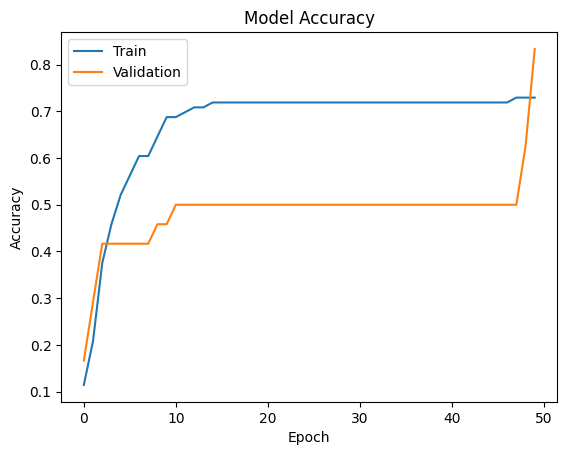

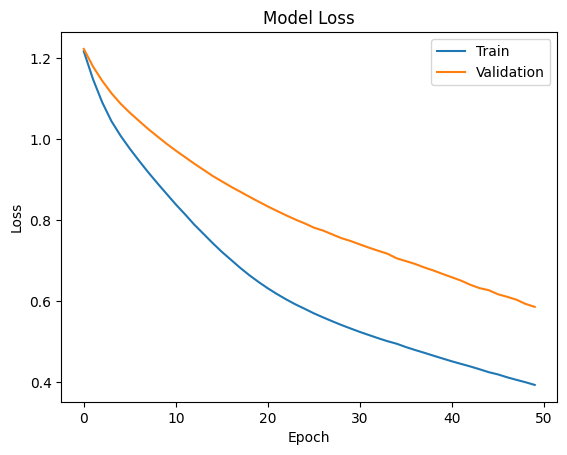

In [14]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()